In [2]:
using Distributions
using MCMCChains
using Random
using StatsPlots
using Turing

Turing.turnprogress(false)

┌ Info: [Turing]: global PROGRESS is set as false
└ @ Turing /Users/dsp/.julia/packages/Turing/LONxt/src/Turing.jl:25


false

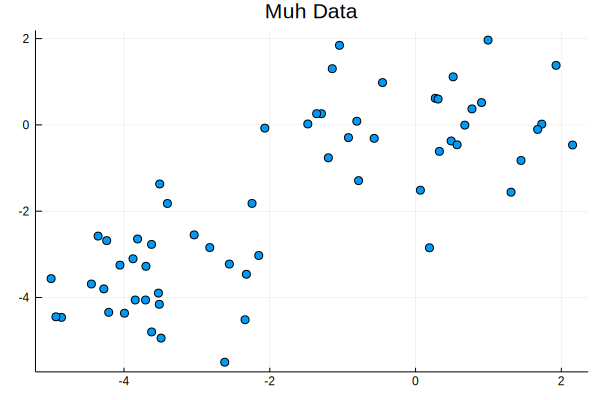

In [3]:
#Random.seed!(497)
N = 30 # pts per cluster
mus = [-3.5, 0.]
x = mapreduce(c -> rand(MvNormal([mus[c], mus[c]], 1.), N), hcat, 1:2)
scatter(x[1, :], x[2, :], legend=false, title="Muh Data")

In [4]:
@model GaussianMixtureModel(x) = begin
    D, N = size(x)
    mu1 ~ Normal() # cluster 1 params
    mu2 ~ Normal() # cluster 2
    mu = [mu1, mu2]
    #alpha = 1.
    #w ~ Dirichlet(2, alpha)
    w = [0.5, 0.5]
    k = Vector{Int}(undef, N)
    for i in 1:N
        k[i] ~ Categorical(w)
        x[:, i] ~ MvNormal([mu[k[i]], mu[k[i]]], 1.)
    end
    k
end

(::DynamicPPL.ModelGen{(:x,),var"###GaussianMixtureModel#301",NamedTuple{(),Tuple{}}}) (generic function with 1 method)

In [5]:
gmm = GaussianMixtureModel(x)

DynamicPPL.Model{var"##inner_function#275#4",NamedTuple{(:x,),Tuple{Array{Float64,2}}},DynamicPPL.ModelGen{(:x,),var"###GaussianMixtureModel#301",NamedTuple{(),Tuple{}}},Val{()}}(var"##inner_function#275#4"(), (x = [-3.0374357378087735 -4.277570414944699 … -1.357029760977841 0.9947722245445711; -2.549148787645145 -3.8004690981831244 … 0.2604820895791242 1.9657715630503887],), DynamicPPL.ModelGen{(:x,),var"###GaussianMixtureModel#301",NamedTuple{(),Tuple{}}}(##GaussianMixtureModel#301, NamedTuple()), Val{()}())

In [ ]:
gmm_sampler = Gibbs(PG(100, :k), HMC(0.05, 10, :mu1, :mu2))
tchain = mapreduce(c -> sample(gmm, gmm_sampler, 100), chainscat, 1:3)

In [ ]:
ids = findall(map(name -> occursin("mu", name), names(tchain)))
p = plot(tchain[:, ids, :], 
         legend=true, 
         labels=["µ1", "µ2"], 
         colordim=:parameter)

In [ ]:
function predict(x, y, w, mu)
    return Turing.logaddexp(
        log(w[1]) + logpdf(MvNormal([mu[1], mu[1]], 1.), [x, y]),
        log(w[2]) + logpdf(MvNormal([mu[2], mu[2]], 1.), [x, y]))
end

In [ ]:
contour(
    range(-5, stop=3), 
    range(-6, stop=2), 
    (x, y) -> predict(x, 
                      y, 
                      [0.5, 0.5], 
                      [mean(tchain[:mu1].value), 
                       mean(tchain[:mu2].value)]))
scatter!(x[1, :], x[2, :], legend=false, title="Muh Data")

In [ ]:
assignments = collect(skipmissing(mean(tchain[:k].value, dims=1).data))
scatter(x[1, :], 
        x[2, :], 
        legend=false, 
        title="Assignments", 
        zcolor=assignments)